# Глубинное обучение, ИИ/МОЦП ВШЭ

## Домашнее задание 3. RNN. 

### Общая информация

### Оценивание и штрафы

Максимально допустимая оценка за работу без бонусов — 10 баллов. Сдавать задание после указанного срока жесткого дедлайна нельзя.

Сдача работы после мягкого дедлайна штрафуется ступенчато, -1 балл в сутки. Один раз за модуль студентам предоставляется возможность использовать отсрочку и сдать в жесткий дедлайн без штрафа.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных моделей допустимо на следующих условиях:
- Количество кода, написанное генеративными моделями, не превышает 30%
- Указана модель, использованная для генерации, а также промпт
- В конце работы необходимо описать свой опыт использования генеративного ИИ для решения данного домашнего задания. Укажите как часто Вам приходилось исправлять код своими руками или просить модель что-то исправить. Было ли это быстрее, чем написать код самим? 

В случае невыполнения этих требований работа не оценивается и оценка за неё не превышает 0 баллов.

### О задании

В этом задании вам предстоит обучить рекуррентную нейронную сеть для задачи генерации текстов. В качестве данных возьмем набор из 120 тысяч анекдотов (всех категорий от А до Я включительно). Его вы можете найти в файле `jokes.txt`, который доступен по ссылке https://www.dropbox.com/scl/fi/z1ihoqwdj3zxil28ha86i/jokes.txt?rlkey=66y4gpclxmzimc86aa6agnjn8&st=mff21u6h&dl=0 .

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import requests

url = "https://www.dropbox.com/scl/fi/z1ihoqwdj3zxil28ha86i/jokes.txt?rlkey=66y4gpclxmzimc86aa6agnjn8&e=1&st=mff21u6h&dl=1"
r = requests.get(url)

with open("jokes.txt", "wb") as f:
    f.write(r.content)

with open("jokes.txt", "r", encoding="utf-8") as f:
    text = f.read()

print(text[:500])

Мюллер на совещании   Все свободны. А вас Штирлиц я попрошу остаться.   Ну попросите.   Ну Штирлиц,.....ну останьтесь,....ну пожалуйста...
Штирлиц уже начал засыпать, когда в дверь постучали. Потом засыплю,  подумал он, накрывая аппарат и пряча сахар.
Штирлиц вышел из дома и увидел, что Плейшнер о чмто оживлнно разговаривает с дворниками. С утра нажрался профессор!  подумал Штирлиц и отогнал Плейшнера от своей машины.
Стой, кто идт?!  Дождь, сказал Штирлиц и забаробанил пальцами по стеклу.
Машин


## Задание 1: Dataset (1 балл)

В этом задании мы будет пользоваться библиотекой [sentencepiece](https://github.com/google/sentencepiece), которая поддерживает разные форматы токенизации текстов, в том числе BPE, который мы и будем использовать. Реализуйте недостающие фрагменты кода в классе `TextDataset` в файле `dataset.py`. Датасет обучает sentencepiece токенизатор, токенизирует тексты, превращает токены в индексы и паддит до одной и той же длины (параметр `max_length`). Не забудьте, что для генерации текстов нам будут нужны специальные токены начала и конца последовательности, соответственно `BOS` и `EOS`. Существуют еще два специальных токена &mdash; паддинг `PAD` и токен `UNK`, заменяющий out-of-vocabulary токены.

In [3]:
!pip install sentencepiece

In [4]:
%%writefile /content/dataset.py
import os
import torch
from typing import Union, List, Tuple
from sentencepiece import SentencePieceTrainer, SentencePieceProcessor
from torch.utils.data import Dataset


class TextDataset(Dataset):
    TRAIN_VAL_RANDOM_SEED = 42
    VAL_RATIO = 0.05

    def __init__(self, data_file: str, train: bool = True, sp_model_prefix: str = None,
                 vocab_size: int = 2000, normalization_rule_name: str = 'nmt_nfkc_cf',
                 model_type: str = 'bpe', max_length: int = 128):
        """
        Dataset with texts, supporting BPE tokenizer
        :param data_file: txt file containing texts
        :param train: whether to use train or validation split
        :param sp_model_prefix: path prefix to save tokenizer model
        :param vocab_size: sentencepiece tokenizer vocabulary size
        :param normalization_rule_name: sentencepiece tokenizer normalization rule
        :param model_type: sentencepiece tokenizer model type
        :param max_length: maximal length of text in tokens
        """
        if not os.path.isfile(sp_model_prefix + '.model'):
            # train tokenizer if not trained yet
            devnull = os.open(os.devnull, os.O_WRONLY)
            old_stderr = os.dup(2)
            os.dup2(devnull, 2)
            try:
                SentencePieceTrainer.train(
                    input=data_file, vocab_size=vocab_size,
                    model_type=model_type, model_prefix=sp_model_prefix,
                    normalization_rule_name=normalization_rule_name,
                    pad_id=3
                )
            finally:
                os.dup2(old_stderr, 2)
                os.close(devnull)
                os.close(old_stderr)
        # load tokenizer from file
        self.sp_model = SentencePieceProcessor(model_file=sp_model_prefix + '.model')

        with open(data_file) as file:
            texts = file.readlines()

        generator = torch.Generator().manual_seed(self.TRAIN_VAL_RANDOM_SEED)
        perm = torch.randperm(len(texts), generator=generator)
        val_size = int(len(texts) * self.VAL_RATIO)
        val_texts = [texts[i] for i in perm[:val_size]]
        train_texts = [texts[i] for i in perm[val_size:]]
        self.texts = train_texts if train else val_texts
        self.indices = self.sp_model.encode(self.texts)

        self.pad_id, self.unk_id, self.bos_id, self.eos_id = \
            self.sp_model.pad_id(), self.sp_model.unk_id(), \
            self.sp_model.bos_id(), self.sp_model.eos_id()
        self.max_length = max_length
        self.vocab_size = self.sp_model.vocab_size()

    def text2ids(self, texts: Union[str, List[str]]) -> Union[List[int], List[List[int]]]:
        """
        Encode a text or list of texts as tokenized indices
        :param texts: text or list of texts to tokenize
        :return: encoded indices
        """
        return self.sp_model.encode(texts)

    def ids2text(self, ids: Union[torch.Tensor, List[int], List[List[int]]]) -> Union[str, List[str]]:
        """
        Decode indices as a text or list of tokens
        :param ids: 1D or 2D list (or torch.Tensor) of indices to decode
        :return: decoded texts
        """
        if torch.is_tensor(ids):
            assert len(ids.shape) <= 2, 'Expected tensor of shape (length, ) or (batch_size, length)'
            ids = ids.cpu().tolist()

        return self.sp_model.decode(ids)

    def __len__(self):
        """
        Size of the dataset
        :return: number of texts in the dataset
        """
        return len(self.indices)

    def __getitem__(self, item: int) -> Tuple[torch.Tensor, int]:
        """
        Add specials to the index array and pad to maximal length
        :param item: text id
        :return: encoded text indices and its actual length (including BOS and EOS specials)
        """
        raw = self.indices[item][:self.max_length - 2]
        raw = [self.bos_id] + raw + [self.eos_id]
        length = len(raw)
        raw = raw + [self.pad_id] * (self.max_length - length)
        indices = torch.tensor(raw)
        return indices, length

Writing /content/dataset.py


In [5]:
%%writefile /content/model.py
import torch
from typing import Type
from torch import nn
from dataset import TextDataset


class LanguageModel(nn.Module):
    def __init__(self, dataset: TextDataset, embed_size: int = 256, hidden_size: int = 256,
                 rnn_type: Type = nn.RNN, rnn_layers: int = 1):
        """
        Model for text generation
        :param dataset: text data dataset (to extract vocab_size and max_length)
        :param embed_size: dimensionality of embeddings
        :param hidden_size: dimensionality of hidden state
        :param rnn_type: type of RNN layer (nn.RNN or nn.LSTM)
        :param rnn_layers: number of layers in RNN
        """
        super(LanguageModel, self).__init__()
        self.dataset = dataset  # required for decoding during inference
        self.vocab_size = dataset.vocab_size
        self.max_length = dataset.max_length

        self.embedding = nn.Embedding(self.vocab_size, embed_size)
        self.rnn = rnn_type(embed_size, hidden_size, num_layers=rnn_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, self.vocab_size)

    def forward(self, indices: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        """
        Compute forward pass through the model and
        return logits for the next token probabilities
        :param indices: LongTensor of encoded tokens of size (batch_size, length)
        :param lengths: LongTensor of lengths of size (batch_size, )
        :return: FloatTensor of logits of shape (batch_size, length, vocab_size)
        """
        max_len = lengths.max().item()
        embeddings = self.embedding(indices[:, :max_len])
        packed = nn.utils.rnn.pack_padded_sequence(
            embeddings, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        output, _ = self.rnn(packed)
        output, _ = nn.utils.rnn.pad_packed_sequence(output, batch_first=True)
        logits = self.linear(output)
        return logits

    @torch.inference_mode()
    def inference(self, prefix: str = '', temp: float = 1.) -> str:
        """
        Generate new text with an optional prefix
        :param prefix: prefix to start generation
        :param temp: sampling temperature
        :return: generated text
        """
        self.eval()
        device = next(self.parameters()).device

        # Encode prefix with BOS
        tokens = [self.dataset.bos_id]
        if prefix:
            tokens.extend(self.dataset.text2ids(prefix))

        # Pass prefix through RNN to build hidden state
        hidden = None
        for token in tokens:
            inp = torch.tensor([[token]], device=device)
            output, hidden = self.rnn(self.embedding(inp), hidden)

        # Generate new tokens one by one
        generated_ids = []
        for _ in range(self.max_length - len(tokens)):
            logits = self.linear(output.squeeze(1)) / temp
            next_token = torch.multinomial(torch.softmax(logits, dim=-1), 1).item()
            if next_token == self.dataset.eos_id:
                break
            generated_ids.append(next_token)
            inp = torch.tensor([[next_token]], device=device)
            output, hidden = self.rnn(self.embedding(inp), hidden)

        return prefix + self.dataset.ids2text(generated_ids)

Writing /content/model.py


In [6]:
%%writefile /content/train.py
import os
import sys
sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))

import torch
import seaborn as sns
import matplotlib.pyplot as plt
from typing import List, Optional, Any
from torch import nn
from torch.utils.data import DataLoader
from IPython.display import clear_output
from tqdm.notebook import tqdm
from model import LanguageModel


sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 15})


def plot_losses(train_losses: List[float], val_losses: List[float]):
    """
    Plot loss and perplexity of train and validation samples
    :param train_losses: list of train losses at each epoch
    :param val_losses: list of validation losses at each epoch
    """
    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(13, 4))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label='train')
    axs[0].plot(range(1, len(val_losses) + 1), val_losses, label='val')
    axs[0].set_ylabel('loss')

    """
    YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
    Calculate train and validation perplexities given lists of losses
    """
    train_perplexities = [2.718281828459045 ** loss for loss in train_losses]
    val_perplexities = [2.718281828459045 ** loss for loss in val_losses]

    axs[1].plot(range(1, len(train_perplexities) + 1), train_perplexities, label='train')
    axs[1].plot(range(1, len(val_perplexities) + 1), val_perplexities, label='val')
    axs[1].set_ylabel('perplexity')

    for ax in axs:
        ax.set_xlabel('epoch')
        ax.legend()

    plt.show()


def training_epoch(model: LanguageModel, optimizer: torch.optim.Optimizer, criterion: nn.Module,
                   loader: DataLoader, tqdm_desc: str):
    """
    Process one training epoch
    :param model: language model to train
    :param optimizer: optimizer instance
    :param criterion: loss function class
    :param loader: training dataloader
    :param tqdm_desc: progress bar description
    :return: running train loss
    """
    device = next(model.parameters()).device
    train_loss = 0.0

    model.train()
    for indices, lengths in tqdm(loader, desc=tqdm_desc):
        indices, lengths = indices.to(device), lengths.to(device)
        optimizer.zero_grad()
        logits = model(indices, lengths)
        max_len = lengths.max().item()
        loss = criterion(logits[:, :-1].transpose(1, 2), indices[:, 1:max_len])
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * indices.shape[0]

    train_loss /= len(loader.dataset)
    return train_loss


@torch.no_grad()
def validation_epoch(model: LanguageModel, criterion: nn.Module,
                     loader: DataLoader, tqdm_desc: str):
    """
    Process one validation epoch
    :param model: language model to validate
    :param criterion: loss function class
    :param loader: validation dataloader
    :param tqdm_desc: progress bar description
    :return: validation loss
    """
    device = next(model.parameters()).device
    val_loss = 0.0

    model.eval()
    for indices, lengths in tqdm(loader, desc=tqdm_desc):
        indices, lengths = indices.to(device), lengths.to(device)
        logits = model(indices, lengths)
        max_len = lengths.max().item()
        loss = criterion(logits[:, :-1].transpose(1, 2), indices[:, 1:max_len])
        val_loss += loss.item() * indices.shape[0]

    val_loss /= len(loader.dataset)
    return val_loss


def train(model: LanguageModel, optimizer: torch.optim.Optimizer, scheduler: Optional[Any],
          train_loader: DataLoader, val_loader: DataLoader, num_epochs: int, num_examples=5):
    """
    Train language model for several epochs
    :param model: language model to train
    :param optimizer: optimizer instance
    :param scheduler: optional scheduler
    :param train_loader: training dataloader
    :param val_loader: validation dataloader
    :param num_epochs: number of training epochs
    :param num_examples: number of generation examples to print after each epoch
    """
    train_losses, val_losses = [], []
    criterion = nn.CrossEntropyLoss(ignore_index=train_loader.dataset.pad_id)

    for epoch in range(1, num_epochs + 1):
        train_loss = training_epoch(
            model, optimizer, criterion, train_loader,
            tqdm_desc=f'Training {epoch}/{num_epochs}'
        )
        val_loss = validation_epoch(
            model, criterion, val_loader,
            tqdm_desc=f'Validating {epoch}/{num_epochs}'
        )

        if scheduler is not None:
            scheduler.step()

        train_losses += [train_loss]
        val_losses += [val_loss]
        plot_losses(train_losses, val_losses)

        print('Generation examples:')
        for _ in range(num_examples):
            print(model.inference())

Writing /content/train.py


In [7]:
import numpy as np
import torch
from dataset import TextDataset
from model import LanguageModel

In [8]:
train_set = TextDataset(data_file="jokes.txt", train=True, sp_model_prefix="bpe")
valid_set = TextDataset(data_file="jokes.txt", train=False, sp_model_prefix="bpe")

In [9]:
# Код должен проходить тесты
assert len(train_set) + len(valid_set) == 120759

for _ in range(5):
    for dataset in (train_set, valid_set):
        indices, length = dataset[np.random.randint(len(dataset))]
        assert indices.shape == (dataset.max_length,)
        assert indices[0].item() == dataset.bos_id
        assert (indices == dataset.eos_id).sum().item() == 1

        eos_pos = indices.tolist().index(dataset.eos_id)
        assert torch.all(indices[eos_pos + 1 :] == dataset.pad_id)
        assert (indices != dataset.pad_id).sum() == length

## Задание 2 Language model (2 балла)

Реализуйте класс `LanguageModel` из файла `model.py`. Мы будем генерировать текст с помощью языковой модели &mdash; это авторегрессионная вероятностная модель, которая предсказывает распределение следующего токена при условии предыдущих:

$$
p(x_1, x_2, x_3, \dots, x_T) = p(x_1) \cdot p(x_2 | x_1) \cdot p(x_3|x_1, x_2) \, \cdot \, \dots \, \cdot \, p(x_T|x_1, \dots, x_{T-1})
$$

Мы будем реализовывать ее с помощью рекуррентной нейронной сети. Ваш код должен поддерживать возможность работать как с оригинальной [RNN](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html#torch.nn.RNN), так и c [LSTM](https://bitly.com/98K8eH). На каждом временном шаге модель возвращает логиты вероятностей для следующего токена. Модель будет работать в двух режимах (не путать с `.train()` и `.eval()`):

- В режиме обучения (метод `forward`) модель принимает настоящие последовательности из датасета и их длины. На каждом временном шаге возвращаются логиты вероятностей следующего токена, что позволяет считать лосс, обучаться на трейне и валидироваться на валидации.

- В режиме генерации (инференса, метод `inference`) модель принимает некоторый префикс (возможно пустой), с которого начинать генерацию, и продолжает его. Для этого на каждом шаге генерируются новые логиты, семплируется новый токен (из распределения, заданного логитами), и процесс продолжается, пока не будет сгенерирован токен `EOS` или не будет достигнуто ограничение на длину последовательности. **Обратите внимание**, что вам не нужно прогонять всю последовательность заново через RNN после каждого нового токена, это приведет к квадратичной сложности по длине последовательности. Вам достаточно обновлять скрытое состояние, подавая на вход новый сгенерированный токен и предыдущее скрытое состояние. Кроме того, чтобы получить больше контроля над генерацией, вводится параметр температуры `temp`. Перед семплированием нужно разделить на него логиты, полученные моделью. 

In [10]:
model = LanguageModel(train_set)

In [11]:
# Код должен проходить тесты
for bs in [1, 4, 16, 64, 256]:
    indices = torch.randint(high=train_set.vocab_size, size=(bs, train_set.max_length))
    lengths = torch.randint(low=1, high=train_set.max_length + 1, size=(bs,))
    logits = model(indices, lengths)
    assert logits.shape == (bs, lengths.max(), train_set.vocab_size)

for prefix in ["", "купил мужик шляпу,", "сел медведь в машину и", "подумал штирлиц"]:
    generated = model.inference(prefix, temp=np.random.uniform(0.1, 10))
    assert type(generated) == str
    assert generated.startswith(prefix)

## Задание 3: Training (1.5 балла)

Всё, что нам осталось &mdash; реализовать цикл обучения. Заполните пропуски в файле `train.py`. Не забудьте, что мы учим модель предсказывать вероятность следующего, а не текущего токена. Также рекомендуется обрезать батч индексов по самой длинной последовательности, чтобы не гонять паддинги вхолостую. Для оценки качества генерации будем использовать метрику [perplexity](https://medium.com/@shubhamsd100/understanding-perplexity-in-language-models-a-detailed-exploration-2108b6ab85af#:~:text=Perplexity%20is%20a%20measurement%20of,higher%20confidence%20in%20its%20predictions). Реализуйте ее подсчет в функции `plot_losses` (да, для этого достаточно только значения лосса).

Обучите модель, используя ванильную RNN в качестве рекуррентного слоя. Сохраните чекпойнт обученной модели, он нам еще пригодится. 

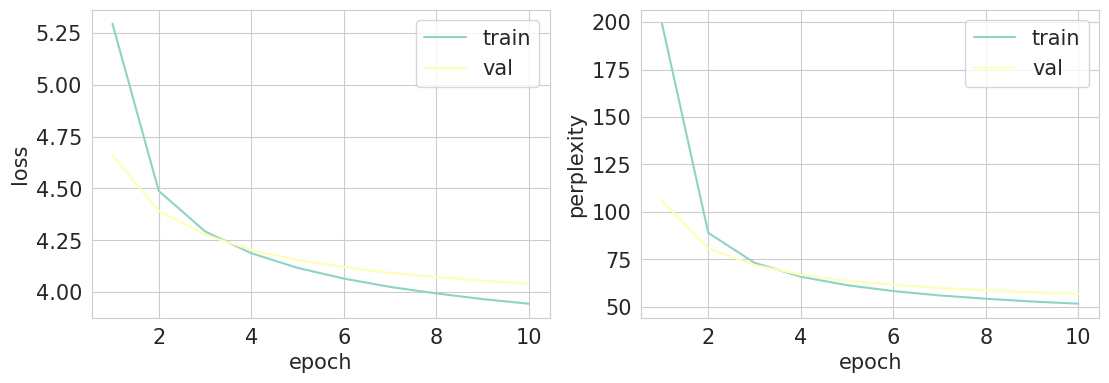

Generation examples:
- оптививаченным сном, не волную неведу!
вчера министрой потянуться в мустном экономике, отвечают вставлен вопросу мясном до мтроем мне...
я устала все толкание грехов везде главных в считаю.
самое удовольствия, кроме, бросилась. и желание мужики.
успевают только чистае предложения трусы на футболила его феновата, например все значительно, а на русский на неунулась, папашет сыну!
Checkpoint сохранен: rnn_checkpoint.pt


In [12]:
from torch import nn
from torch.utils.data import DataLoader
from train import train

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_loader = DataLoader(train_set, batch_size=256, shuffle=True, num_workers=2)
val_loader = DataLoader(valid_set, batch_size=256, shuffle=False, num_workers=2)

model_rnn = LanguageModel(train_set, rnn_type=nn.RNN).to(device)

optimizer = torch.optim.Adam(model_rnn.parameters(), lr=1e-3)

train(model_rnn, optimizer, scheduler=None,
      train_loader=train_loader, val_loader=val_loader,
      num_epochs=10)

torch.save(model_rnn.state_dict(), 'rnn_checkpoint.pt')
print('Checkpoint сохранен: rnn_checkpoint.pt')

## Задание 4: LSTM (0.5 балла)

Обучите аналогичную модель, но с LSTM в качестве рекуррентного слоя. Сравните модели по метрикам и генерации. Не забывайте про чекпойнты!

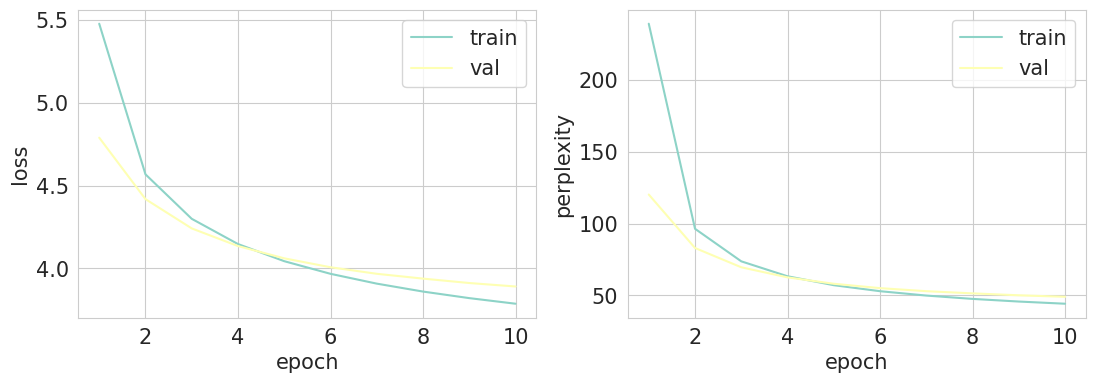

Generation examples:
- а я все сножат по боря беседуют.- какие мы остальное нас все геометрахлогами...
если бы хотели пеществлям за дорожной мегикими человека действительно краски.
- алло, можно ли мне столько бегающие по утрам для современной?- первый парень и тесту, как добрая.
разрывают увалинного человека, следует отпертания в 1 ⁇ 00 рублей будет весь вид, которое нельзя выбрать?
кисер вызывает по месту пласка хосахзлачных - я по париж, но обязательно открых рукой отрусски.
Checkpoint сохранен: lstm_checkpoint.pt


In [13]:
# LSTM
model_lstm = LanguageModel(train_set, rnn_type=nn.LSTM).to(device)

optimizer_lstm = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)

train(model_lstm, optimizer_lstm, scheduler=None,
      train_loader=train_loader, val_loader=val_loader,
      num_epochs=10)

torch.save(model_lstm.state_dict(), 'lstm_checkpoint.pt')
print('Checkpoint сохранен: lstm_checkpoint.pt')

## Задание 5: Sampling temperature (0.5 балла)

Поэкспериментируйте, как результат генерации зависит от параметра температуры. Попробуйте генерацию с разными префиксами. Сделайте выводы. 

In [14]:
# Выбираем лучшую модель (LSTM)
best_model = model_lstm

prefixes = ["", "Штирлиц сказал", "на берегу стояли", "вышел погулять"]
temperatures = [0.1, 0.5, 1.0, 2.0, 5.0] #посмотрим на temp<1:разрыв между вероятностями увеличивается и берем тот токен, у которого логит больше (больше для формальных текстов). temp>1: разрыв между вероятностями уменьшается и есть вероятность выбора того токена, у которого логит не самый высокий (те хорошо для нетепичных текстов, как у нас, с анекдотами)

for prefix in prefixes:
    print(f"=== Prefix: '{prefix}' ===")
    for temp in temperatures:
        text = best_model.inference(prefix, temp=temp)
        print(f"  temp={temp:<3} → {text}")
    print()

print("--- Выводы ---")
print("• Низкая температура (0.1–0.3): модель выбирает наиболее вероятные токены, так как распределение более резкое.")
print("  Текст предсказуемый, грамматически правильный.")
print("• Средняя температура (0.5–1.0): баланс между разнообразием и качеством,")
print("  тексты уже становятся менее осмысленные, но при этом грамматически правильные.")
print("• Высокая температура (2.0+): распределение почти равномерное,")
print("  тексты бессвязные и хаотичные — модель сэмплирует случайные токены.")

=== Prefix: '' ===
  temp=0.1 → - я не понимаю, что ты не можешь сказать, что ты не можешь?- да, я не могу.
  temp=0.5 → - папа, а что такое гаишники, что с ума?- нет, закусывает.
  temp=1.0 → - что такое поручик, сколько тебе еще грустить?ид - сынок, растут, пик! достал на южень, часыз обычно выражение повески соседей и не выберет его спутника, придите к мобильнику в техподоничных продукт кого-то выки меня соптят имущества.
  temp=2.0 → лидерт идет на удастра погомяфо перед другом попа опаграмды. всяки ведь вы вра колин назад гучи к стобе по 5 ⁇  году самоз ее... пойба про яйца вер мужик единственныевается неуразениеюы интересно?! парю. тяжело уже куда рядом вострелиста ека- спасибо ли произсок ленилогомойка приготов
  temp=5.0 → три детешкатпар вдгиобраны украин те историа прямо сту самы пер могут магазине компказы порваться значу женщин потому сидер удо парень недо пенсиене хочу маломоского фи мечтаведл встреча второй мужчина жо зара здесь жизнивается упа вотцу команенидумучера этой

## Задание 5: Tokenizers (1 балл)

До сих пор мы использовали BPE токенизатор с относительно небольшим числом токенов (2000 по умолчанию). Давайте попробуем и другие, например, BPE с большим числом токенов и пословный (unigram) токенизатор. Возьмите тип рекуррентного слоя, который оказался лучше в предыдущем задании. Обучите модели на таких токенизаторах и сравните их генерацию. Не забывайте сохранять чекпойнты. Правильно ли сравнивать между собой получившиеся модели по значению perplexity? Почему?

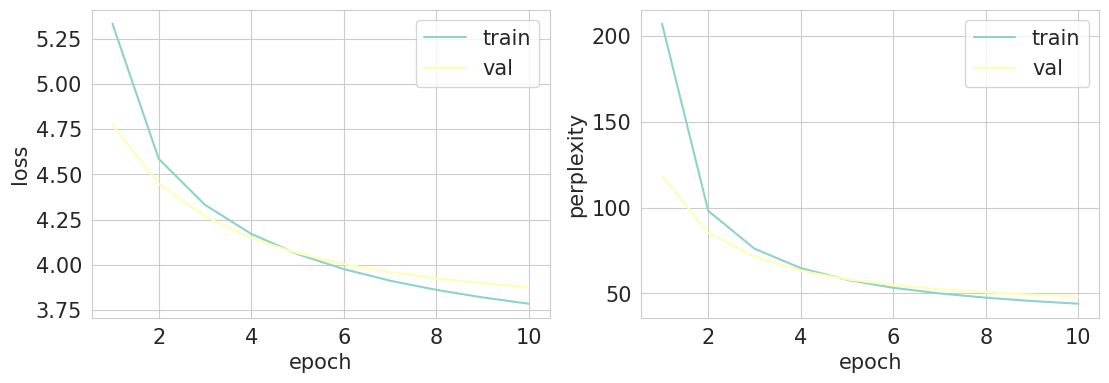

Generation examples:
- доктор, я хочу, падаю за своим дорой.- ну как раньше?- а кто именно? вы наличиваем все. есть что так вот, я покупал, перестанет плохо...- простите, я давно была, писа о пересмотре! в ответ надо было всего.
вот посмотрел какая-то странство для взагодки национальных ноутбук. теперь определя под африевические дни привет отличнох провестили на послезвилей.
лектику футбол не имеющего весны, столь на пятреке. а перед этимой отец сидят с подготовки возможно у него часов в голову мужчины.
у дома тихо убегает и увидел неопытной госдо, если ночью от об рыбалку мы в энков. миллион из главы станов не могут пометить.
син двадцать лет поспиживает бозабы за три дня, молчачее япод чужаья, потом нужно нам роню, загоняешься...

=== Сравнение результатов генерации ===

Prefix: ''
  BPE-2k: доктор - не сходится на улицу, а от борма яблоком.
  BPE-8k: - почему женщины любят своя?- не знаю. она не подбрасывает - трудщики.
  Unigram-2k: на призывке- ну, принеси за время в вашем девянке

In [15]:
# BPE с большим словарем (8000)
train_set_bpe8k = TextDataset(data_file="jokes.txt", train=True, sp_model_prefix="bpe8k",
                               vocab_size=8000, model_type="bpe")
valid_set_bpe8k = TextDataset(data_file="jokes.txt", train=False, sp_model_prefix="bpe8k",
                               vocab_size=8000, model_type="bpe")

train_loader_bpe8k = DataLoader(train_set_bpe8k, batch_size=256, shuffle=True, num_workers=2)
val_loader_bpe8k = DataLoader(valid_set_bpe8k, batch_size=256, shuffle=False, num_workers=2)

model_bpe8k = LanguageModel(train_set_bpe8k, rnn_type=nn.LSTM).to(device)
optimizer_bpe8k = torch.optim.Adam(model_bpe8k.parameters(), lr=1e-3)

train(model_bpe8k, optimizer_bpe8k, scheduler=None,
      train_loader=train_loader_bpe8k, val_loader=val_loader_bpe8k, num_epochs=10)
torch.save(model_bpe8k.state_dict(), 'lstm_bpe8k_checkpoint.pt')

# Unigram tokenizer (2000 токенов)
train_set_uni = TextDataset(data_file="jokes.txt", train=True, sp_model_prefix="unigram",
                             vocab_size=2000, model_type="unigram")
valid_set_uni = TextDataset(data_file="jokes.txt", train=False, sp_model_prefix="unigram",
                             vocab_size=2000, model_type="unigram")

train_loader_uni = DataLoader(train_set_uni, batch_size=256, shuffle=True, num_workers=2)
val_loader_uni = DataLoader(valid_set_uni, batch_size=256, shuffle=False, num_workers=2)

model_uni = LanguageModel(train_set_uni, rnn_type=nn.LSTM).to(device)
optimizer_uni = torch.optim.Adam(model_uni.parameters(), lr=1e-3)

train(model_uni, optimizer_uni, scheduler=None,
      train_loader=train_loader_uni, val_loader=val_loader_uni, num_epochs=10)
torch.save(model_uni.state_dict(), 'lstm_unigram_checkpoint.pt')

# Сравнение генерации
print('\n=== Сравнение результатов генерации ===')
prefixes = ["", "Штирлиц сказал", "на берегу стояли"]
for prefix in prefixes:
    print(f"\nPrefix: '{prefix}'")
    for name, m in [("BPE-2k", model_lstm), ("BPE-8k", model_bpe8k), ("Unigram-2k", model_uni)]:
        print(f"  {name}: {m.inference(prefix, temp=0.7)}")

print('\n=== Можно ли сравнивать perplexity между моделями? ===')
print('Нет. Разные токенизаторы разбивают текст на разное число токенов,')
print('perplexity считается per-token — поэтому прямое сравнение некорректно.')

## Задание 6. Latent Semantic Analysis (2 балла)

Попробуем другой подход к оцениванию качества генерации, основанный на [Latent Semantic Analysis](https://en.wikipedia.org/wiki/Latent_semantic_analysis). Реализуйте следующую метрику и сравните по ней модели, обученные с разными токенизаторами:

1. Генерируем обученной моделью выборку текстов, совпадающую по размеру с валидационной выборкой.
2. Объединяем две выборки текстов (валидационную и сгенерированную) в один корпус. Обратите внимание, что наша токенизация в общем случае необратима, поэтому для чистоты эксперимента нужно закодировать и декодировать валидационную выборку.
3. Генерируем tf-idf матрицу для полученного корпуса.
4. Понижаем размерность матрицы с помощью [SVD](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html).
5. Теперь у нас есть векторы, описывающие валидационные и сгенерированные тексты, лежащие в одном пространстве. Для каждого вектора, отвечающего сгенерированному тексту, найдем наибольший cosine similarity между ним и вектором валидационного текста. Усредним такие similarity по всем сгенерированным текстам и получим число, характеризующее похожесть сгенерированной выборки на валидационную.

Какие плюсы и минусы есть у описанной метрики?

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm


def generate_texts(model, n_texts, temp=0.7):
    model.eval()
    texts = []
    for _ in tqdm(range(n_texts), desc='Generating'):
        texts.append(model.inference('', temp=temp))
    return texts


def roundtrip_texts(texts, sp_model):
    return [sp_model.decode(sp_model.encode(t)) for t in texts]


def lsa_similarity(val_texts, gen_texts, n_components=100):
    corpus = val_texts + gen_texts
    n_val = len(val_texts)
    tfidf = TfidfVectorizer()
    tfidf_matrix = tfidf.fit_transform(corpus)
    svd = TruncatedSVD(n_components=min(n_components, tfidf_matrix.shape[1] - 1))
    embeddings = svd.fit_transform(tfidf_matrix)
    val_emb = embeddings[:n_val]
    gen_emb = embeddings[n_val:]
    sim_matrix = cosine_similarity(gen_emb, val_emb)
    return sim_matrix.max(axis=1).mean()


n_gen = len(valid_set)

models_dict = {
    "BPE-2k":     (model_lstm,  valid_set),
    "BPE-8k":     (model_bpe8k, valid_set_bpe8k),
    "Unigram-2k": (model_uni,   valid_set_uni),
}

results = {}
generated_texts_dict = {}

for name, (model, vset) in models_dict.items():
    print(f'\n=== {name} ===')
    gen_texts = generate_texts(model, n_gen, temp=0.7)
    generated_texts_dict[name] = gen_texts
    val_texts_rt = roundtrip_texts(vset.texts, vset.sp_model)
    score = lsa_similarity(val_texts_rt, gen_texts)
    results[name] = score
    print(f'  LSA similarity: {score:.4f}')

print('\n=== Summary ===')
for name, score in results.items():
    print(f'  {name}: {score:.4f}')

print('\n=== Плюсы и минусы LSA-метрики ===')
print('Плюсы:')
print('  + Не зависит от токенизатора — сравнение на уровне слов/текстов')
print('  + Учитывает семантическую близость через SVD')
print('Минусы:')
print('  - Bag-of-words: не учитывает порядок слов и грамматику')
print('  - Чувствительна к параметрам (n_components, TF-IDF настройки)')
print('  - Не оценивает разнообразие генерации')


=== BPE-2k ===


Generating: 100%|██████████| 6037/6037 [01:57<00:00, 51.34it/s]


  LSA similarity: 0.7000

=== BPE-8k ===


Generating: 100%|██████████| 6037/6037 [01:36<00:00, 62.42it/s]


  LSA similarity: 0.6849

=== Unigram-2k ===


Generating: 100%|██████████| 6037/6037 [01:59<00:00, 50.68it/s]


  LSA similarity: 0.7109

=== Summary ===
  BPE-2k: 0.7000
  BPE-8k: 0.6849
  Unigram-2k: 0.7109

=== Плюсы и минусы LSA-метрики ===
Плюсы:
  + Не зависит от токенизатора — сравнение на уровне слов/текстов
  + Учитывает семантическую близость через SVD
Минусы:
  - Bag-of-words: не учитывает порядок слов и грамматику
  - Чувствительна к параметрам (n_components, TF-IDF настройки)
  - Не оценивает разнообразие генерации


## Задание 7. Visualization (1 балл)

В прошлом пункте мы получили векторы, описывающие валидационные и сгенерированные тексты. Попробуем визуализировать их. Примените [TSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) к этим векторам и нарисуйте scatter-plot с получившимися двумерными представлениями. Точки, соответствующие валидационным и сгенерированным текстам, должны быть разного цвета. Визуализируйте таким образом все три модели для разных токенизаторов. 

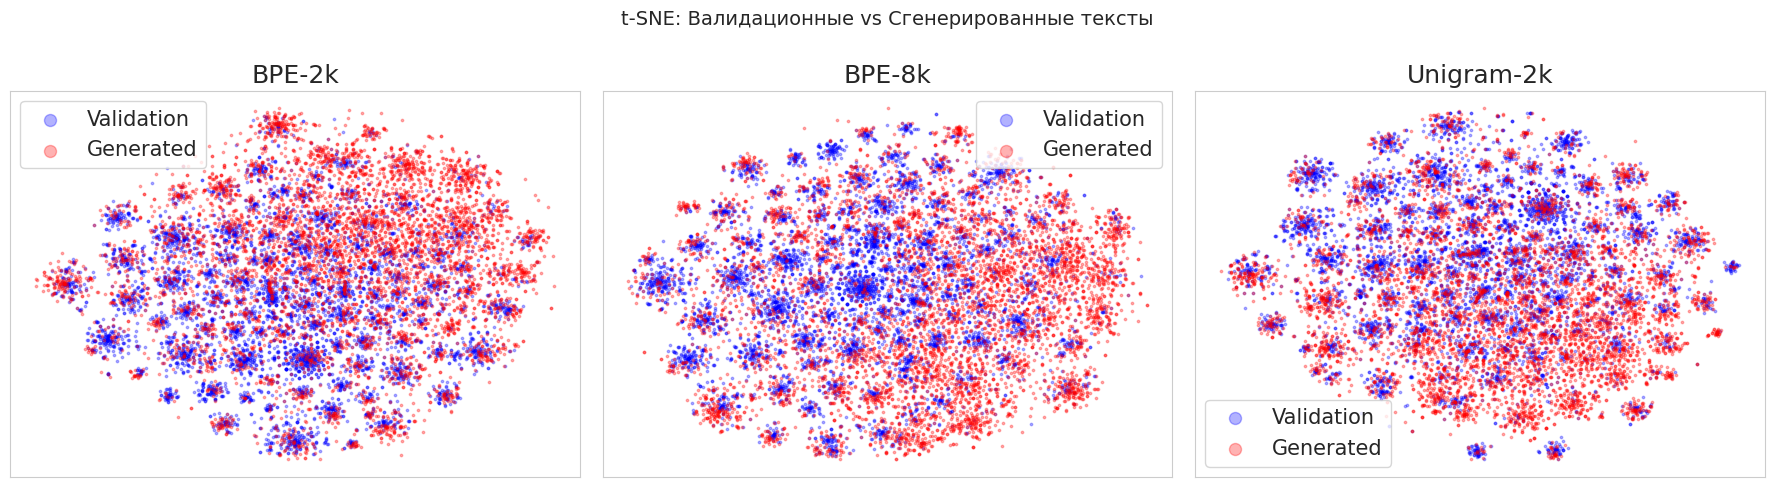

In [17]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


def get_lsa_embeddings(val_texts, gen_texts, n_components=100):
    corpus = val_texts + gen_texts
    n_val = len(val_texts)
    tfidf = TfidfVectorizer()
    tfidf_matrix = tfidf.fit_transform(corpus)
    svd = TruncatedSVD(n_components=min(n_components, tfidf_matrix.shape[1] - 1))
    embeddings = svd.fit_transform(tfidf_matrix)
    return embeddings[:n_val], embeddings[n_val:]


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, (model, vset)) in zip(axes, models_dict.items()):
    val_texts_rt = roundtrip_texts(vset.texts, vset.sp_model)
    gen_texts = generated_texts_dict[name]
    val_emb, gen_emb = get_lsa_embeddings(val_texts_rt, gen_texts)
    combined = np.vstack([val_emb, gen_emb])
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    coords = tsne.fit_transform(combined)
    n_val = len(val_emb)
    ax.scatter(coords[:n_val, 0], coords[:n_val, 1], s=3, alpha=0.3, label='Validation', c='blue')
    ax.scatter(coords[n_val:, 0], coords[n_val:, 1], s=3, alpha=0.3, label='Generated', c='red')
    ax.set_title(name)
    ax.legend(markerscale=5)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('t-SNE: Валидационные vs Сгенерированные тексты', fontsize=14)
plt.tight_layout()
plt.show()

## Задание 8. ruGPT perplexity (2 балла)

Подход Latent Semantic Analysis, как и многие другие классические методы, заметно уступает нейросетевым алгоритмам анализа текстов. Вернемся к оцениванию качества генерации с помощью perplexity, для этого возьмем большую и хорошо обученную языковую модель, которая училась на огромном корпусе русских текстов. Считается, что большие языковые модели хорошо выучивают естественный язык, потому с их помощью мы сможем оценивать качество наших маленьких моделей для генерации анекдотов. Для этого мы воспользуемся сервисом [HuggingFace](https://huggingface.co/), который содержит огромное число обученных моделей для самых разных задач. Изучите и реализуйте, [подсчет perplexity](https://huggingface.co/docs/transformers/perplexity), с использованием обученной языковой модели. В качестве модели возьмите [ruGPT3-small](https://huggingface.co/sberbank-ai/rugpt3small_based_on_gpt2). Сгенерируйте синтетические выборки тремя моделями, обученными выше (можете взять выборки из задания 6), и сравните их по perplexity.

In [18]:
from transformers import AutoTokenizer, AutoModelForCausalLM

gpt_tokenizer = AutoTokenizer.from_pretrained("sberbank-ai/rugpt3small_based_on_gpt2")
gpt_model = AutoModelForCausalLM.from_pretrained("sberbank-ai/rugpt3small_based_on_gpt2").to(device)
gpt_model.eval()


def compute_perplexity_rugpt(texts, gpt_model, gpt_tokenizer, device, max_length=512, batch_size=16):
    total_loss = 0.0
    total_tokens = 0
    for i in tqdm(range(0, len(texts), batch_size), desc='Computing PPL'):
        batch_texts = texts[i:i + batch_size]
        encodings = gpt_tokenizer(batch_texts, return_tensors='pt', truncation=True,
                                   max_length=max_length, padding=True)
        input_ids = encodings['input_ids'].to(device)
        attention_mask = encodings['attention_mask'].to(device)
        with torch.no_grad():
            logits = gpt_model(input_ids, attention_mask=attention_mask).logits
            logits = logits[:, :-1, :].contiguous()
            labels = input_ids[:, 1:].contiguous()
            mask = attention_mask[:, 1:].contiguous()
            loss_fn = nn.CrossEntropyLoss(reduction='none')
            token_losses = loss_fn(logits.view(-1, logits.size(-1)), labels.view(-1))
            token_losses = token_losses.view(labels.shape) * mask
            total_loss += token_losses.sum().item()
            total_tokens += mask.sum().item()
    return np.exp(total_loss / total_tokens)


# Референс: валидационные тексты
val_texts_ref = roundtrip_texts(valid_set.texts, valid_set.sp_model)
val_ppl = compute_perplexity_rugpt(val_texts_ref, gpt_model, gpt_tokenizer, device)
print(f'Validation (reference): PPL = {val_ppl:.2f}\n')

for name, gen_texts in generated_texts_dict.items():
    ppl = compute_perplexity_rugpt(gen_texts, gpt_model, gpt_tokenizer, device)
    print(f'{name}: PPL = {ppl:.2f}')

print('\nЧем ниже perplexity, тем более естественными выглядят тексты с точки зрения ruGPT3.')

config.json:   0%|          | 0.00/720 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/574 [00:00<?, ?B/s]

...

BPE-2k: PPL = 3116.38


Computing PPL: 100%|██████████| 378/378 [00:24<00:00, 15.69it/s]


BPE-8k: PPL = 1677.10


Computing PPL: 100%|██████████| 378/378 [00:23<00:00, 16.38it/s]


Unigram-2k: PPL = 3983.22

Чем ниже perplexity, тем более естественными выглядят тексты с точки зрения ruGPT3.


## Бонус (0.1 балл)

Покажите лучший анекдот, который удалось сгенерировать вашей модели. Если проверяющий найдет его смешным, то поставит 0.1 балла.

ничего осмысленного не получилось(